633834
7984179
4300046


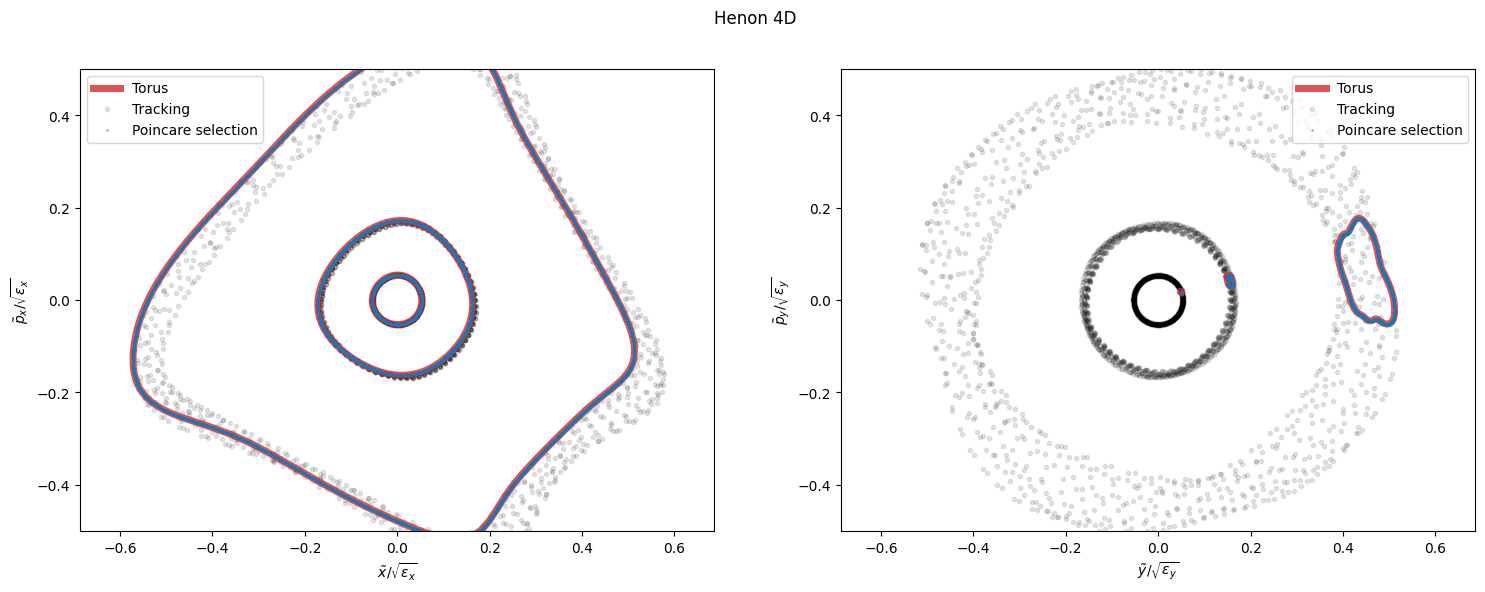

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as sciStat
import nafflib

import sys
sys.path.append('/Users/pbelanger/ABPLocal/pytori')
import pytori.torus as pytorus




# Henon parameters:
# ---
nturns = int(1e6)
# points = np.array([0.1,0.2,0.3,0.4,0.41,0.45,0.51,0.555])
# points = np.array([0.4])
points = np.array([0.05,0.15,0.4])[::-1]

slope  = 0.35

coupling = 0.25
Qx_list = [0.2064898024701758,0.2264898024701758, (3 - np.sqrt(5)) / 2]
Qx = 0.24464898024701758
Qy = np.sqrt(2) - 1
# ------------

particles = []
for point in points:
    
    # Tracking
    x,px,y,py = nafflib.henon_map_4D(point,slope*point,point,slope*point,   Qx = Qx,
                                                                            Qy = Qy,
                                                                            coupling = coupling,
                                                                            num_turns= nturns)
    # Saving
    dct = {'x':x,'px':px,'y':y,'py':py}
    particles.append(dct)


n_harm = 126
from fractions import Fraction
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
plt.suptitle('Henon 4D')
for p_idx,part in enumerate(particles):
    
    fundamental_tunes = [nafflib.tune(part[plane][:int(5e4)],part[f'p{plane}'][:int(5e4)],window_order=4) for plane in ['x','y']]

    N_start = 0

    supersampling = np.arange(1,int(1e7))
    superperiod = int(supersampling[np.argmin(np.abs(np.round(supersampling*fundamental_tunes[1])-supersampling*fundamental_tunes[1]))])
    print(superperiod)
    N_r = np.arange(int(1e4))*superperiod

    Ax,Qx  = nafflib.harmonics( part['x'][:int(5e4)],part[f'px'][:int(5e4)],num_harmonics = n_harm,window_order=4)
    Cx,err,_f = nafflib.find_linear_combinations(Qx,fundamental_tunes=fundamental_tunes,max_harmonic_order=40)
    # x_r,px_r = nafflib.generate_pure_KAM(amplitudes, combi, fundamental_tunes, N_r)
    x_r,px_r = nafflib.generate_signal(Ax,Qx, N_start + N_r)

    Ay,Qy  = nafflib.harmonics( part['y'][:int(5e4)],part[f'py'][:int(5e4)],num_harmonics = n_harm,window_order=4)
    Cy,err,_f = nafflib.find_linear_combinations(Qy,fundamental_tunes=fundamental_tunes,max_harmonic_order=40)
    # combi,err,_f = nafflib.find_linear_combinations(frequencies,fundamental_tunes=fundamental_tunes,max_harmonic_order=40)
    # y_r,py_r = nafflib.generate_pure_KAM(amplitudes, combi, fundamental_tunes,N_r)
    y_r,py_r = nafflib.generate_signal(Ay,Qy, N_start + N_r)


    mytorus = pytorus.Torus(Ax,Ay,Cx,Cy)
    

    theta_vec   = 2 * np.pi*fundamental_tunes[0]* N_start + np.linspace(0,2*np.pi,1000)
    theta_slice = 2 * np.pi*fundamental_tunes[1]* N_start
    

    slice_x,slice_y = mytorus.slice('x',theta_vec,theta_slice)
    slice_x,slice_y = slice_x[0],slice_y[0]



    plt.sca(axes[0])
    plt.plot(slice_x[:,0],slice_x[:,1],'-',lw=5,color='C3',alpha=0.8,zorder=-10)
    plt.plot(x_r,px_r,'.',ms=2,color='C0',alpha=0.4)

    plt.sca(axes[1])
    plt.plot(slice_y[:,0],slice_y[:,1],'-',lw=5,color='C3',alpha=0.8,zorder=-10)
    plt.plot(y_r,py_r,'.',ms=2,color='C0',alpha=0.4)


    for plane,ax in zip(['x','y'],axes):
        plt.sca(ax)
        plt.plot(part[plane][:1000],part[f'p{plane}'][:1000],'.',color='k',alpha=0.1,zorder=-20)

        #  Ix = np.mean(part[plane][:1000],part[f'p{plane}'][:1000])
        # plt.plot(np.sqrt(Ix)/2*np.cos(theta_vec),np.sqrt(Ix)/2*np.sin(theta_vec),'-',lw=5,color='k',alpha=0.8,zorder=-10)


    # SAVE
    #===============================
    main_mesh = mytorus.to_mesh('x',num_angles=200,num_slices=100,r_forced=5)
    main_mesh.meta['x-px'] = [[_x,_px,0] for _x,_px in zip(part['x'][:1000],part['px'][:1000])]
    # main_mesh.meta['x-px'] = [[_x,_px,0] for _x,_px in zip(part['x'][:1000],part['px'][:1000])]
    main_mesh.to_json(f'data/TORUS_{str(p_idx+1).zfill(3)}_X.json')
    #===============================

# Adding labels
for plane,ax in zip(['x','y','zeta'],axes):
    plt.sca(ax)
    plt.axis('equal')
    if plane == 'zeta':
        plane = '\zeta'
    plt.xlabel(rf'$\tilde {plane}/\sqrt{{\varepsilon_{plane}}}$')
    plt.ylabel(rf'$\tilde p_{plane}/\sqrt{{\varepsilon_{plane}}}$')

    plt.plot(np.nan,np.nan,'-',lw=5,color='C3',alpha=0.8,zorder=-10,label='Torus')
    plt.plot(np.nan,np.nan,'.',color='k',alpha=0.1,label='Tracking')
    plt.plot(np.nan,np.nan,'.',ms=2,color='C0',alpha=0.4,label='Poincare selection')

    plt.legend()

    plt.xlim(-0.5,0.5)
    plt.ylim(-0.5,0.5)


plt.sca(axes[0])
# plt.xlim(-0.5,-0.25)
# plt.ylim(0,0.2)



In [2]:
# part['x'][:1000]

array([ 5.00000000e-02,  2.10448060e-02, -4.84411195e-02, -2.19789594e-02,
        4.73622135e-02,  2.69870277e-02, -4.55050310e-02, -2.85849592e-02,
        4.41481292e-02,  3.34949637e-02, -4.09100210e-02, -3.50790998e-02,
        3.90648890e-02,  3.86922670e-02, -3.51439640e-02, -3.98206715e-02,
        3.38629711e-02,  4.27063486e-02, -2.98576616e-02, -4.43136606e-02,
        2.87060157e-02,  4.70616432e-02, -2.35738053e-02, -4.87025341e-02,
        2.19609262e-02,  5.02345675e-02, -1.61412987e-02, -5.10864740e-02,
        1.49966035e-02,  5.16849016e-02, -9.50166632e-03, -5.25905651e-02,
        8.68257621e-03,  5.31985814e-02, -2.64546455e-03, -5.40475269e-02,
        1.28123429e-03,  5.38335949e-02,  5.21574033e-03, -5.35535616e-02,
       -6.40398131e-03,  5.24671988e-02,  1.21088252e-02, -5.17328000e-02,
       -1.29157078e-02,  5.08922109e-02,  1.84371113e-02, -5.00121154e-02,
       -1.98474532e-02,  4.88910580e-02,  2.55232190e-02, -4.67244743e-02,
       -2.70572524e-02,  

---
# Export for Blender
---

In [2]:
main_mesh = mytorus.to_mesh('x',num_angles=200,num_slices=100,r_forced=5)
main_mesh.to_json('data/TORUS_001_X.json')


---
# Matplotlib tests
---

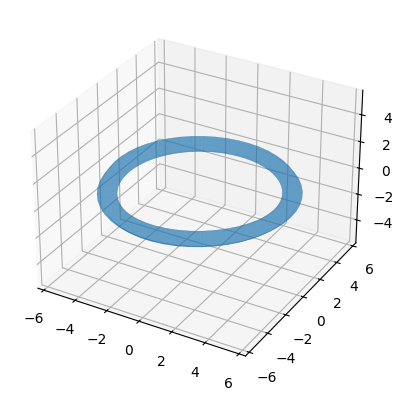

In [3]:

main_mesh = mytorus.to_mesh('x',num_angles=200,num_slices=50,r_forced=5)

main_mesh.to_pickle('torus_henon.pkl')
main_mesh.to_json('torus_henon.json')



main_mesh = mytorus.to_mesh('x',num_angles=200,num_slices=50,r_forced=5)
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Generate the polygons for each face

poly3d = [[main_mesh.verts[vert_id] for vert_id in face] for face in main_mesh.faces]

# Create a Poly3DCollection object
collection = Poly3DCollection(poly3d, edgecolors='k', linewidths=0, alpha=0.5)
ax.add_collection3d(collection)

# Corrected auto scaling
scale = np.concatenate(main_mesh.verts).flatten()  # Corrected here
ax.auto_scale_xyz(scale, scale, scale)

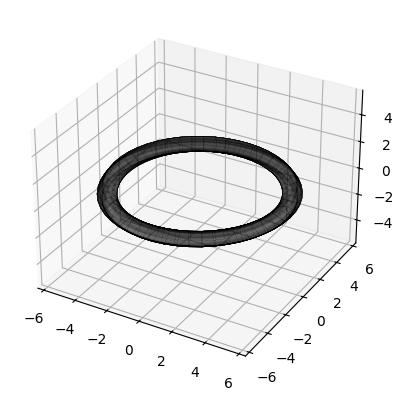

In [4]:
from mpl_toolkits.mplot3d.art3d import Line3DCollection
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

verts = main_mesh.verts
faces = main_mesh.faces

# Create lines for the wireframe
edges = set()
for face in faces:
    face_edges = [(face[i], face[(i+1) % len(face)]) for i in range(len(face))]
    for edge in face_edges:
        edges.add(tuple(sorted(edge)))  # Add each edge as a sorted tuple to avoid duplicates

# Convert edge vertices to line segments for plotting
lines = [[verts[edge[0]], verts[edge[1]]] for edge in edges]

# Create a Line3DCollection from the lines
line_collection = Line3DCollection(lines, colors='k', linewidths=0.1)

# Add the collection to the plot
ax.add_collection(line_collection)

# # Setting the limits to frame the wireframe (might need adjusting)
# ax.set_xlim([verts[:,0].min(), verts[:,0].max()])
# ax.set_ylim([verts[:,1].min(), verts[:,1].max()])
# ax.set_zlim([verts[:,2].min(), verts[:,2].max()])
ax.auto_scale_xyz(scale, scale, scale)

plt.show()